# Experiment 03: Single-image DenseNet121 + HybridChenOrdinalLoss + Class Imbalance Handling

This notebook continues after the baseline and loss-comparison experiment.

**Goal:** keep the model as **single-image DenseNet121**, keep the selected **HybridChenOrdinalLoss**, and compare three training-set imbalance handling methods:

1. **WeightedRandomSampler**
2. **Class-weighted HybridChenOrdinalLoss**
3. **Focal HybridChenOrdinalLoss**

This is a clean experiment: no 4-crop training, no CLAHE training, no GLCM, no CS-MHC, no ensemble.

## 1. Imports & Environment Setup

In [49]:
from pathlib import Path
import os
import random
import json
import math
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models, datasets

from PIL import Image

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration Section

All major experimental settings are stored in one dictionary to make the experiment reproducible.

In [50]:
CONFIG = {
   "IMG_SIZE": 224,
   "BATCH_SIZE": 16,
   "EPOCHS": 30,
   "LR": 1e-4,
   "WEIGHT_DECAY": 0.0,
   "SEED": 42,
   "MODEL_NAME": "DenseNet121",
   "LOSS": "HybridChenOrdinalLoss",
   "NUM_CLASSES": 5,
   "ORDINAL_ALPHA": 0.10,
   "PENALTY_DISTANCE": 2,
   "SQUARE_LOSS": False,
   "NORMALIZE_MATRIX": True,
   "FOCAL_GAMMA": 2.0,
   "PATIENCE": 7,
   "USE_AMP": True,
   "NUM_WORKERS": 2,
}

EXPERIMENT_NAME = "exp03_single_image_hybrid_chen_imbalance_comparison"

OUTPUT_DIR = Path("/kaggle/working") / EXPERIMENT_NAME
RESULTS_DIR = OUTPUT_DIR / "results"
MODELS_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"

for p in [OUTPUT_DIR, RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

print("\nOutput directory:", OUTPUT_DIR)

CONFIG:
  IMG_SIZE: 224
  BATCH_SIZE: 16
  EPOCHS: 30
  LR: 0.0001
  WEIGHT_DECAY: 0.0
  SEED: 42
  MODEL_NAME: DenseNet121
  LOSS: HybridChenOrdinalLoss
  NUM_CLASSES: 5
  ORDINAL_ALPHA: 0.1
  PENALTY_DISTANCE: 2
  SQUARE_LOSS: False
  NORMALIZE_MATRIX: True
  FOCAL_GAMMA: 2.0
  PATIENCE: 7
  USE_AMP: True
  NUM_WORKERS: 2

Output directory: /kaggle/working/exp03_single_image_hybrid_chen_imbalance_comparison


## 3. Dataset Paths

The dataset root must directly contain:

```text
train/
val/
test/
```

In [51]:
# Change this path to your own dataset folder.
# The folder should contain train/, val/, and test/.
DATA_ROOT = Path("/kaggle/input/YOUR_DATASET_NAME/split-data")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

print("Dataset paths are valid.")

DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test
Dataset paths are valid.


## 4. Seed Fixing

A fixed seed is used to improve reproducibility.

In [52]:
def set_seed(seed=42):
   random.seed(seed)
   np.random.seed(seed)
   torch.manual_seed(seed)
   torch.cuda.manual_seed_all(seed)
   torch.backends.cudnn.benchmark = True

set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. Data Preprocessing

To keep this experiment clean, all three imbalance-handling methods use the same deterministic preprocessing:

- Resize
- ToTensor
- Normalize

No random augmentation is used here, because the goal is to compare imbalance-handling strategies only.

CLAHE is shown only as a preview in the visualization section; it is **not** used for training in this notebook.

In [53]:
train_transform = transforms.Compose([
   transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
   transforms.ToTensor(),
   transforms.Normalize(
       mean=[0.485, 0.456, 0.406],
       std=[0.229, 0.224, 0.225]
   )
])

val_transform = transforms.Compose([
   transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
   transforms.ToTensor(),
   transforms.Normalize(
       mean=[0.485, 0.456, 0.406],
       std=[0.229, 0.224, 0.225]
   )
])

test_transform = val_transform

print("Training preprocessing:", train_transform)
print("Validation/test preprocessing:", val_transform)

Training preprocessing: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Validation/test preprocessing: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 6. Dataset & Dataloader

This section loads train/validation/test data and prints the split sizes and class distribution.

Train size: 1024
Val size: 146
Test size: 294
Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}


,split,class_idx,class_name,count,percentage
0,train,0,0Normal,316,0.308594
1,train,1,1Doubtful,308,0.300781
2,train,2,2Mild,134,0.130859
3,train,3,3Moderate,122,0.119141
4,train,4,4Severe,144,0.140625
5,val,0,0Normal,45,0.308219
6,val,1,1Doubtful,44,0.301370
7,val,2,2Mild,19,0.130137
8,val,3,3Moderate,18,0.123288
9,val,4,4Severe,20,0.136986


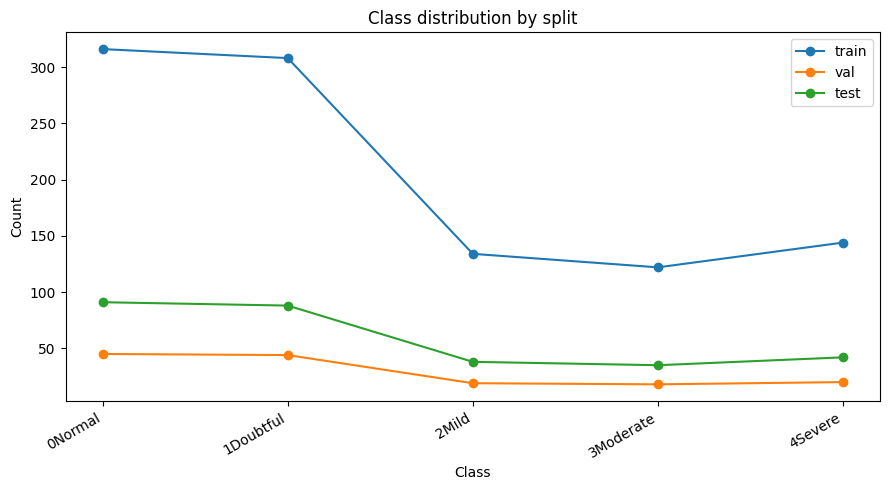

Regular dataloaders created.


In [54]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))
print("Class mapping:", class_to_idx)

def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)
    return np.array([label for _, label in dataset.samples])

train_targets = get_targets(train_dataset)
val_targets = get_targets(val_dataset)
test_targets = get_targets(test_dataset)

def build_distribution_df():
    rows = []
    for split_name, targets in [
        ("train", train_targets),
        ("val", val_targets),
        ("test", test_targets),
    ]:
        counts = np.bincount(targets, minlength=len(class_names))
        for i, cname in enumerate(class_names):
            rows.append({
                "split": split_name,
                "class_idx": i,
                "class_name": cname,
                "count": int(counts[i]),
                "percentage": float(counts[i] / counts.sum())
            })
    return pd.DataFrame(rows)

dist_df = build_distribution_df()
display(dist_df)

plt.figure(figsize=(9, 5))
for split_name in ["train", "val", "test"]:
    temp = dist_df[dist_df["split"] == split_name]
    plt.plot(temp["class_name"], temp["count"], marker="o", label=split_name)

plt.title("Class distribution by split")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

train_loader_regular = DataLoader(
    train_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=(device.type == "cuda")
)

print("Regular dataloaders created.")

### 6.1 Imbalance-handling methods

The original training distribution is imbalanced:

```text
0Normal: 316
1Doubtful: 308
2Mild: 134
3Moderate: 122
4Severe: 144
```

This notebook compares three methods:

1. **WeightedRandomSampler**: changes sampling frequency during training.
2. **Class-weighted HybridChenOrdinalLoss**: changes the CE component weight.
3. **Focal HybridChenOrdinalLoss**: focuses learning on harder examples.

Train class counts:
0 0Normal: 316
1 1Doubtful: 308
2 2Mild: 134
3 3Moderate: 122
4 4Severe: 144


,class_idx,class_name,train_count,class_weight
0,0,0Normal,316,0.648101
1,1,1Doubtful,308,0.664935
2,2,2Mild,134,1.528358
3,3,3Moderate,122,1.678689
4,4,4Severe,144,1.422222


,class_name,original_train_count,weighted_sampler_one_epoch_count
0,0Normal,316,321
1,1Doubtful,308,325
2,2Mild,134,323
3,3Moderate,122,298
4,4Severe,144,313


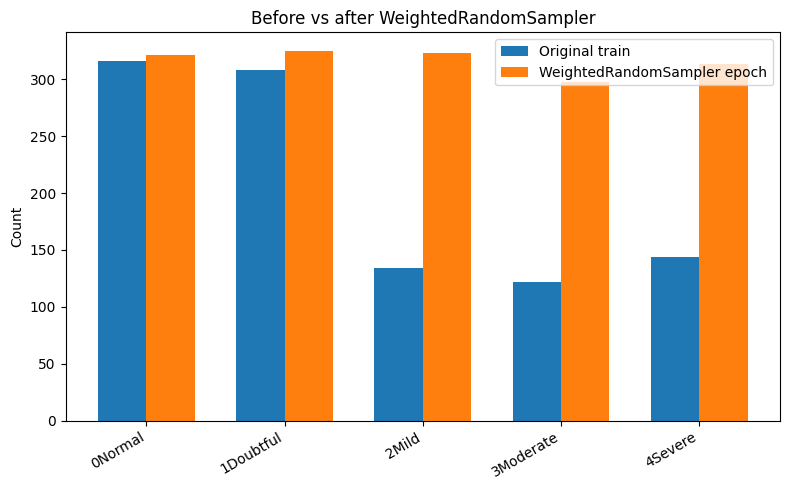

In [55]:
train_class_counts = np.bincount(train_targets, minlength=len(class_names))
num_classes = len(class_names)

print("Train class counts:")
for i, cname in enumerate(class_names):
    print(f"{i} {cname}: {train_class_counts[i]}")

raw_class_weights = train_class_counts.sum() / (num_classes * train_class_counts)
class_weights = torch.tensor(raw_class_weights, dtype=torch.float32)

class_weight_df = pd.DataFrame({
    "class_idx": list(range(num_classes)),
    "class_name": class_names,
    "train_count": train_class_counts,
    "class_weight": raw_class_weights,
})
display(class_weight_df)

class_sample_weights = 1.0 / train_class_counts
sample_weights = class_sample_weights[train_targets]
sample_weights = torch.DoubleTensor(sample_weights)

num_samples_per_epoch = int(train_class_counts.max() * num_classes)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=num_samples_per_epoch,
    replacement=True
)

train_loader_weighted_sampler = DataLoader(
    train_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    sampler=weighted_sampler,
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=(device.type == "cuda")
)

sampled_indices = list(iter(weighted_sampler))
sampled_targets = train_targets[sampled_indices]
sampled_counts = np.bincount(sampled_targets, minlength=num_classes)

sampler_df = pd.DataFrame({
    "class_name": class_names,
    "original_train_count": train_class_counts,
    "weighted_sampler_one_epoch_count": sampled_counts,
})
display(sampler_df)

plt.figure(figsize=(8, 5))
x = np.arange(num_classes)
width = 0.35
plt.bar(x - width/2, sampler_df["original_train_count"], width, label="Original train")
plt.bar(x + width/2, sampler_df["weighted_sampler_one_epoch_count"], width, label="WeightedRandomSampler epoch")
plt.xticks(x, class_names, rotation=30, ha="right")
plt.ylabel("Count")
plt.title("Before vs after WeightedRandomSampler")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weighted_sampler_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Visualization

This section shows:

1. Raw original image
2. Transform after resize/normalization, denormalized for display
3. CLAHE preview
4. Four anatomical crop preview only

The 4-crop preview is only a visual explanation. This notebook still trains a **single-image DenseNet121** model.

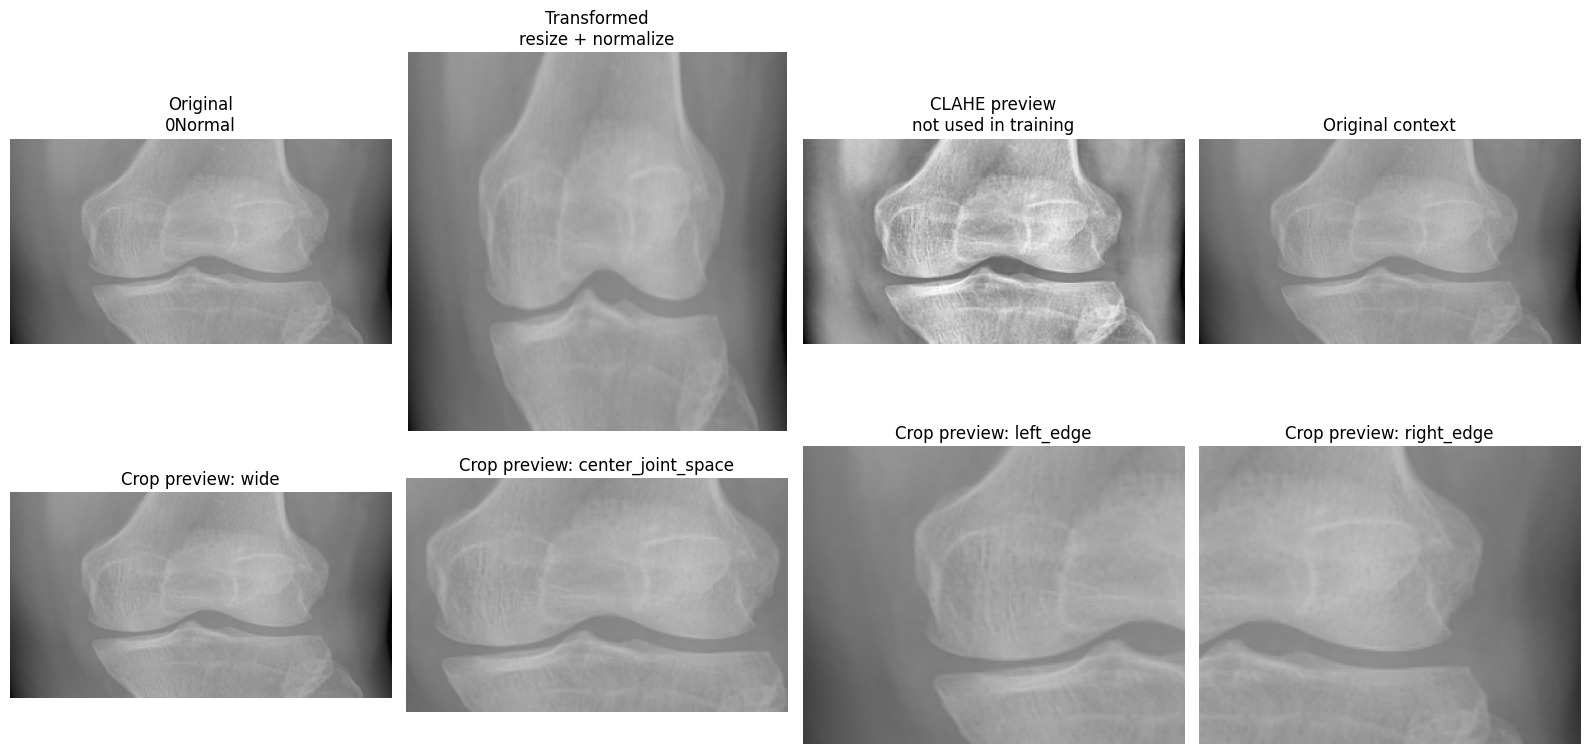

In [56]:
def denormalize_tensor(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def apply_clahe_preview(pil_img):
    try:
        import cv2
        gray = np.array(pil_img.convert("L"))
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        out = clahe.apply(gray)
        return out
    except Exception as e:
        print("CLAHE preview skipped because cv2 is unavailable:", e)
        return np.array(pil_img.convert("L"))

def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = max(1, int(width * width_ratio))
    crop_h = max(1, int(height * height_ratio))
    cx = int(width * center_x_ratio)
    cy = int(height * center_y_ratio)
    left = max(0, min(cx - crop_w // 2, width - crop_w))
    top = max(0, min(cy - crop_h // 2, height - crop_h))
    return (left, top, left + crop_w, top + crop_h)

def show_raw_transform_clahe_and_crop(dataset, sample_idx=0):
    img_path, label = dataset.samples[sample_idx]
    raw_img = Image.open(img_path).convert("RGB")
    transformed_tensor, _ = dataset[sample_idx]
    transformed_img = denormalize_tensor(transformed_tensor)
    clahe_img = apply_clahe_preview(raw_img)

    w, h = raw_img.size
    crop_boxes = {
        "wide": (0, 0, w, h),
        "center_joint_space": make_crop_box(w, h, 0.50, 0.50, 0.70, 0.80),
        "left_edge": make_crop_box(w, h, 0.30, 0.50, 0.55, 0.80),
        "right_edge": make_crop_box(w, h, 0.70, 0.50, 0.55, 0.80),
    }

    plt.figure(figsize=(16, 8))

    plt.subplot(2, 4, 1)
    plt.imshow(raw_img)
    plt.title(f"Original\n{class_names[label]}")
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.imshow(transformed_img)
    plt.title("Transformed\nresize + normalize")
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.imshow(clahe_img, cmap="gray")
    plt.title("CLAHE preview\nnot used in training")
    plt.axis("off")

    plt.subplot(2, 4, 4)
    plt.imshow(raw_img)
    plt.title("Original context")
    plt.axis("off")

    for i, (name, box) in enumerate(crop_boxes.items(), start=5):
        crop = raw_img.crop(box)
        plt.subplot(2, 4, i)
        plt.imshow(crop)
        plt.title(f"Crop preview: {name}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "visualization_raw_transform_clahe_crop_preview.png", dpi=200, bbox_inches="tight")
    plt.show()

show_raw_transform_clahe_and_crop(train_dataset, sample_idx=0)

## 8. Model Definition

The model is **single-image DenseNet121**. It receives one full X-ray image and outputs five KL/OA severity classes.

This experiment does not use 4-crop fusion. The purpose is to isolate the effect of class imbalance strategies after selecting HybridChenOrdinalLoss.

In [57]:
def build_densenet121(num_classes=5, dropout=0.3):
    try:
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        print("Loaded DenseNet121 ImageNet pretrained weights.")
    except Exception as e:
        print("Could not load pretrained weights. Falling back to random initialization.")
        print("Reason:", e)
        model = models.densenet121(weights=None)

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )
    return model

model_check = build_densenet121(num_classes=CONFIG["NUM_CLASSES"])
model_check = model_check.to(device)
dummy = torch.randn(2, 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]).to(device)
with torch.no_grad():
    out = model_check(dummy)
print("Dummy output shape:", out.shape)
del model_check, dummy, out
torch.cuda.empty_cache()

Loaded DenseNet121 ImageNet pretrained weights.
Dummy output shape: torch.Size([2, 5])


## 9. Loss Function

The selected loss from the previous experiment is **HybridChenOrdinalLoss**.

It combines normal classification learning with an ordinal penalty:

```text
total_loss = CrossEntropyLoss + alpha × Chen-style ordinal penalty
```

The ordinal penalty discourages large KL-grade mistakes.

In [58]:
class HybridChenOrdinalLoss(nn.Module):
    def __init__(
        self,
        num_classes=5,
        alpha=0.1,
        penalty_distance=2,
        square_loss=False,
        normalize=True,
        class_weights=None,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.clone().detach().float())
        else:
            self.class_weights = None

        penalty_matrix = self._create_penalty_matrix(num_classes, penalty_distance, normalize)
        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)
        distance_matrix = torch.abs(class_indices.unsqueeze(0) - class_indices.unsqueeze(1))
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0

        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value

        return penalty_matrix

    def forward(self, logits, targets, return_parts=False):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights if self.class_weights is not None else None
        )
        probabilities = F.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix[targets.long()]
        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)

        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2

        ordinal_penalty = torch.mean(penalty_per_sample)
        total_loss = ce + self.alpha * ordinal_penalty

        if return_parts:
            return total_loss, ce.detach(), ordinal_penalty.detach()

        return total_loss


class FocalHybridChenOrdinalLoss(nn.Module):
    def __init__(
        self,
        num_classes=5,
        alpha=0.1,
        penalty_distance=2,
        square_loss=False,
        normalize=True,
        gamma=2.0,
        class_weights=None,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize
        self.gamma = gamma

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.clone().detach().float())
        else:
            self.class_weights = None

        base = HybridChenOrdinalLoss(
            num_classes=num_classes,
            alpha=alpha,
            penalty_distance=penalty_distance,
            square_loss=square_loss,
            normalize=normalize,
            class_weights=None
        )
        self.register_buffer("penalty_matrix", base.penalty_matrix.clone())

    def focal_ce_loss(self, logits, targets):
        ce_per_sample = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_per_sample)
        focal_factor = (1.0 - pt) ** self.gamma

        if self.class_weights is not None:
            sample_weights = self.class_weights[targets.long()]
            focal_loss = sample_weights * focal_factor * ce_per_sample
        else:
            focal_loss = focal_factor * ce_per_sample

        return focal_loss.mean()

    def forward(self, logits, targets, return_parts=False):
        focal_ce = self.focal_ce_loss(logits, targets)
        probabilities = F.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix[targets.long()]
        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)

        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2

        ordinal_penalty = torch.mean(penalty_per_sample)
        total_loss = focal_ce + self.alpha * ordinal_penalty

        if return_parts:
            return total_loss, focal_ce.detach(), ordinal_penalty.detach()

        return total_loss


criterion_check = HybridChenOrdinalLoss(
    num_classes=CONFIG["NUM_CLASSES"],
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
)

focal_check = FocalHybridChenOrdinalLoss(
    num_classes=CONFIG["NUM_CLASSES"],
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
    gamma=CONFIG["FOCAL_GAMMA"],
    class_weights=class_weights,
)

print("HybridChenOrdinalLoss penalty matrix:")
print(criterion_check.penalty_matrix)

print("\nFocalHybridChenOrdinalLoss penalty matrix:")
print(focal_check.penalty_matrix)

print("\nClass weights for class-weighted and focal methods:")
print(class_weights)

HybridChenOrdinalLoss penalty matrix:
tensor([[0.0000, 0.3333, 0.5556, 0.7778, 1.0000],
        [0.3333, 0.0000, 0.3333, 0.5556, 0.7778],
        [0.5556, 0.3333, 0.0000, 0.3333, 0.5556],
        [0.7778, 0.5556, 0.3333, 0.0000, 0.3333],
        [1.0000, 0.7778, 0.5556, 0.3333, 0.0000]])

FocalHybridChenOrdinalLoss penalty matrix:
tensor([[0.0000, 0.3333, 0.5556, 0.7778, 1.0000],
        [0.3333, 0.0000, 0.3333, 0.5556, 0.7778],
        [0.5556, 0.3333, 0.0000, 0.3333, 0.5556],
        [0.7778, 0.5556, 0.3333, 0.0000, 0.3333],
        [1.0000, 0.7778, 0.5556, 0.3333, 0.0000]])

Class weights for class-weighted and focal methods:
tensor([0.6481, 0.6649, 1.5284, 1.6787, 1.4222])


## 10. Optimizer & Scheduler

All methods use the same optimizer and scheduler so the comparison is focused on imbalance handling.

In [59]:
def build_optimizer_and_scheduler(model):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["LR"],
        weight_decay=CONFIG["WEIGHT_DECAY"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["EPOCHS"]
    )
    return optimizer, scheduler

print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")

Optimizer: AdamW
Scheduler: CosineAnnealingLR


## 11. Training Loop

The training loop records train loss, validation loss, validation QWK, validation MAE, and validation Macro F1.

The best checkpoint is selected by validation QWK.

In [60]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    mae = float(np.mean(np.abs(y_true - y_pred)))

    diff = np.abs(y_true - y_pred)
    adjacent_errors = int(np.sum(diff == 1))
    distant_errors = int(np.sum(diff >= 2))
    total_errors = int(np.sum(diff != 0))

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "qwk": float(qwk),
        "mae": float(mae),
        "total_errors": total_errors,
        "adjacent_errors": adjacent_errors,
        "distant_errors": distant_errors,
    }

def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0
    y_true, y_pred = [], []

    use_amp = CONFIG["USE_AMP"] and (device.type == "cuda")

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(images)
                loss, ce_part, ord_part = criterion(logits, labels, return_parts=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss, ce_part, ord_part = criterion(logits, labels, return_parts=True)
            loss.backward()
            optimizer.step()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        running_ce += ce_part.item() * bs
        running_ord += ord_part.item() * bs

        preds = torch.argmax(logits.detach(), dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_or_focal_part"] = running_ce / len(loader.dataset)
    metrics["ordinal_part"] = running_ord / len(loader.dataset)
    return metrics

def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0
    y_true, y_pred = [], []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss, ce_part, ord_part = criterion(logits, labels, return_parts=True)

            bs = labels.size(0)
            running_loss += loss.item() * bs
            running_ce += ce_part.item() * bs
            running_ord += ord_part.item() * bs

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(preds.detach().cpu().numpy())
            y_prob.extend(probs.detach().cpu().numpy())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_or_focal_part"] = running_ce / len(loader.dataset)
    metrics["ordinal_part"] = running_ord / len(loader.dataset)

    return metrics, np.array(y_true), np.array(y_pred), np.array(y_prob)

def make_criterion_for_method(method_name):
    if method_name == "weighted_sampler":
        return HybridChenOrdinalLoss(
            num_classes=CONFIG["NUM_CLASSES"],
            alpha=CONFIG["ORDINAL_ALPHA"],
            penalty_distance=CONFIG["PENALTY_DISTANCE"],
            square_loss=CONFIG["SQUARE_LOSS"],
            normalize=CONFIG["NORMALIZE_MATRIX"],
            class_weights=None,
        ).to(device)

    if method_name == "class_weighted_loss":
        return HybridChenOrdinalLoss(
            num_classes=CONFIG["NUM_CLASSES"],
            alpha=CONFIG["ORDINAL_ALPHA"],
            penalty_distance=CONFIG["PENALTY_DISTANCE"],
            square_loss=CONFIG["SQUARE_LOSS"],
            normalize=CONFIG["NORMALIZE_MATRIX"],
            class_weights=class_weights.to(device),
        ).to(device)

    if method_name == "focal_hybrid_loss":
        return FocalHybridChenOrdinalLoss(
            num_classes=CONFIG["NUM_CLASSES"],
            alpha=CONFIG["ORDINAL_ALPHA"],
            penalty_distance=CONFIG["PENALTY_DISTANCE"],
            square_loss=CONFIG["SQUARE_LOSS"],
            normalize=CONFIG["NORMALIZE_MATRIX"],
            gamma=CONFIG["FOCAL_GAMMA"],
            class_weights=class_weights.to(device),
        ).to(device)

    raise ValueError(f"Unknown method: {method_name}")

def make_train_loader_for_method(method_name):
    if method_name == "weighted_sampler":
        return train_loader_weighted_sampler
    return train_loader_regular

def train_one_method(method_name, display_name):
    print("=" * 80)
    print("Training method:", display_name)
    print("=" * 80)

    set_seed(CONFIG["SEED"])
    model = build_densenet121(
        num_classes=CONFIG["NUM_CLASSES"],
        dropout=0.3
    ).to(device)

    criterion = make_criterion_for_method(method_name)
    optimizer, scheduler = build_optimizer_and_scheduler(model)

    scaler = torch.amp.GradScaler("cuda", enabled=(CONFIG["USE_AMP"] and device.type == "cuda"))

    model_path = MODELS_DIR / f"{method_name}_best.pth"
    history = []

    best_val_qwk = -999
    best_epoch = -1
    patience_counter = 0

    start_time = time.time()

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        train_metrics = train_one_epoch(model, make_train_loader_for_method(method_name), criterion, optimizer, scaler)
        val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        row = {
            "method": method_name,
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_qwk={val_metrics['qwk']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "config": CONFIG,
                "method": method_name,
                "best_epoch": best_epoch,
                "best_val_qwk": best_val_qwk,
                "class_names": class_names,
            }, model_path)
            print(f"  Saved best checkpoint: val_qwk={best_val_qwk:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["PATIENCE"]:
                print(f"Early stopping at epoch {epoch}.")
                break

    elapsed = time.time() - start_time
    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"{method_name}_history.csv", index=False)

    print(f"Finished {display_name}. Best epoch: {best_epoch}, Best val QWK: {best_val_qwk:.4f}, Time: {elapsed/60:.1f} min")

    return model_path, history_df

## 12. Validation Section

Each method is selected using validation QWK.  
Validation metrics are recorded during training and saved as history CSV files.

In [61]:
IMBALANCE_METHODS = [
    {
        "method": "weighted_sampler",
        "display_name": "HybridChenOrdinalLoss + WeightedRandomSampler",
        "description": "Balanced sampling frequency during training."
    },
    {
        "method": "class_weighted_loss",
        "display_name": "Class-weighted HybridChenOrdinalLoss",
        "description": "Inverse-frequency class weights inside the CE component."
    },
    {
        "method": "focal_hybrid_loss",
        "display_name": "Focal HybridChenOrdinalLoss",
        "description": "Focal CE component with class weights to focus hard/minority samples."
    },
]

method_paths = {}
histories = {}

for item in IMBALANCE_METHODS:
    method = item["method"]
    display_name = item["display_name"]
    model_path, history_df = train_one_method(method, display_name)
    method_paths[method] = model_path
    histories[method] = history_df

print("All methods trained.")

Training method: HybridChenOrdinalLoss + WeightedRandomSampler
Loaded DenseNet121 ImageNet pretrained weights.
Epoch 01/30 | train_loss=1.5384 | val_loss=0.7108 | val_acc=0.7192 | val_macro_f1=0.6970 | val_qwk=0.8532 | val_mae=0.3767
  Saved best checkpoint: val_qwk=0.8532
Epoch 02/30 | train_loss=0.5750 | val_loss=0.6618 | val_acc=0.7329 | val_macro_f1=0.7207 | val_qwk=0.8602 | val_mae=0.3493
  Saved best checkpoint: val_qwk=0.8602
Epoch 03/30 | train_loss=0.3471 | val_loss=0.6839 | val_acc=0.7466 | val_macro_f1=0.7159 | val_qwk=0.9036 | val_mae=0.2945
  Saved best checkpoint: val_qwk=0.9036
Epoch 04/30 | train_loss=0.2732 | val_loss=0.6555 | val_acc=0.8014 | val_macro_f1=0.7801 | val_qwk=0.8905 | val_mae=0.2603
Epoch 05/30 | train_loss=0.2203 | val_loss=0.6552 | val_acc=0.7945 | val_macro_f1=0.7628 | val_qwk=0.8931 | val_mae=0.2671
Epoch 06/30 | train_loss=0.1179 | val_loss=0.7121 | val_acc=0.7877 | val_macro_f1=0.7820 | val_qwk=0.8813 | val_mae=0.2808
Epoch 07/30 | train_loss=0.0810

## 13. Test Evaluation

The best checkpoint for each imbalance-handling method is evaluated on the test set.

In [62]:
def load_model_from_checkpoint(model_path):
    model = build_densenet121(
        num_classes=CONFIG["NUM_CLASSES"],
        dropout=0.3
    ).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model, checkpoint

test_results = {}
test_predictions = {}

for item in IMBALANCE_METHODS:
    method = item["method"]
    display_name = item["display_name"]

    print("=" * 80)
    print("Test evaluation for:", display_name)
    print("=" * 80)

    model, checkpoint = load_model_from_checkpoint(method_paths[method])
    criterion = make_criterion_for_method(method)

    test_metrics, test_true, test_pred, test_prob = evaluate(model, test_loader, criterion)

    test_results[method] = {
        "display_name": display_name,
        "best_epoch": int(checkpoint["best_epoch"]),
        "best_val_qwk": float(checkpoint["best_val_qwk"]),
        **test_metrics
    }

    test_predictions[method] = {
        "y_true": test_true,
        "y_pred": test_pred,
        "y_prob": test_prob,
    }

    for k, v in test_results[method].items():
        print(f"{k}: {v}")

    print()

results_df = pd.DataFrame(test_results).T
display(results_df)

results_df.to_csv(RESULTS_DIR / "imbalance_method_test_results.csv", index=True)

best_method_by_val = results_df["best_val_qwk"].astype(float).idxmax()
best_method_by_test_qwk = results_df["qwk"].astype(float).idxmax()

print("Best method by validation QWK:", best_method_by_val)
print("Best method by test QWK:", best_method_by_test_qwk)

FINAL_METHOD = best_method_by_val
print("Selected FINAL_METHOD for explanation:", FINAL_METHOD)

Test evaluation for: HybridChenOrdinalLoss + WeightedRandomSampler
Loaded DenseNet121 ImageNet pretrained weights.
display_name: HybridChenOrdinalLoss + WeightedRandomSampler
best_epoch: 3
best_val_qwk: 0.9036203182544645
accuracy: 0.7551020408163265
macro_f1: 0.7406420408400046
weighted_f1: 0.7549914837729963
qwk: 0.8572960923314776
mae: 0.32653061224489793
total_errors: 72
adjacent_errors: 56
distant_errors: 16
loss: 0.7591740916147321
ce_or_focal_part: 0.7462561288658454
ordinal_part: 0.12917960734188963

Test evaluation for: Class-weighted HybridChenOrdinalLoss
Loaded DenseNet121 ImageNet pretrained weights.
display_name: Class-weighted HybridChenOrdinalLoss
best_epoch: 13
best_val_qwk: 0.9210253998118533
accuracy: 0.7959183673469388
macro_f1: 0.789791578960065
weighted_f1: 0.7940888844156618
qwk: 0.8923985997886696
mae: 0.2653061224489796
total_errors: 60
adjacent_errors: 47
distant_errors: 13
loss: 0.7311295146933522
ce_or_focal_part: 0.7212784319330438
ordinal_part: 0.0985108210

,display_name,best_epoch,best_val_qwk,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,loss,ce_or_focal_part,ordinal_part
weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,3,0.90362,0.755102,0.740642,0.754991,0.857296,0.326531,72,56,16,0.759174,0.746256,0.12918
class_weighted_loss,Class-weighted HybridChenOrdinalLoss,13,0.921025,0.795918,0.789792,0.794089,0.892399,0.265306,60,47,13,0.73113,0.721278,0.098511
focal_hybrid_loss,Focal HybridChenOrdinalLoss,18,0.91472,0.778912,0.766943,0.777461,0.832195,0.333333,65,45,20,0.444605,0.431807,0.127986


Best method by validation QWK: class_weighted_loss
Best method by test QWK: class_weighted_loss
Selected FINAL_METHOD for explanation: class_weighted_loss


## 13.1 Per-class Recall and F1

The final report should include class-wise recall and class-wise F1 because overall accuracy can hide poor performance in minority classes.

In [63]:
classification_reports = {}

for item in IMBALANCE_METHODS:
    method = item["method"]
    display_name = item["display_name"]

    y_true = test_predictions[method]["y_true"]
    y_pred = test_predictions[method]["y_pred"]

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).T
    classification_reports[method] = report_df
    report_df.to_csv(RESULTS_DIR / f"{method}_classification_report.csv")

    print("=" * 80)
    print(display_name)
    print("=" * 80)
    display(report_df[["precision", "recall", "f1-score", "support"]])

rows = []
for item in IMBALANCE_METHODS:
    method = item["method"]
    display_name = item["display_name"]
    report_df = classification_reports[method]

    for cname in class_names:
        rows.append({
            "method": method,
            "display_name": display_name,
            "class_name": cname,
            "recall": report_df.loc[cname, "recall"],
            "f1_score": report_df.loc[cname, "f1-score"],
            "support": report_df.loc[cname, "support"],
        })

classwise_compare_df = pd.DataFrame(rows)
display(classwise_compare_df)
classwise_compare_df.to_csv(RESULTS_DIR / "classwise_recall_f1_comparison.csv", index=False)

HybridChenOrdinalLoss + WeightedRandomSampler


,precision,recall,f1-score,support
0Normal,0.884615,0.758242,0.816568,91.000000
1Doubtful,0.682692,0.806818,0.739583,88.000000
2Mild,0.529412,0.473684,0.500000,38.000000
3Moderate,0.800000,0.800000,0.800000,35.000000
4Severe,0.837209,0.857143,0.847059,42.000000
accuracy,0.755102,0.755102,0.755102,0.755102
macro avg,0.746786,0.739177,0.740642,294.000000
weighted avg,0.761420,0.755102,0.754991,294.000000


Class-weighted HybridChenOrdinalLoss


,precision,recall,f1-score,support
0Normal,0.822917,0.868132,0.844920,91.000000
1Doubtful,0.739130,0.772727,0.755556,88.000000
2Mild,0.709677,0.578947,0.637681,38.000000
3Moderate,0.857143,0.857143,0.857143,35.000000
4Severe,0.875000,0.833333,0.853659,42.000000
accuracy,0.795918,0.795918,0.795918,0.795918
macro avg,0.800773,0.782057,0.789792,294.000000
weighted avg,0.794716,0.795918,0.794089,294.000000


Focal HybridChenOrdinalLoss


,precision,recall,f1-score,support
0Normal,0.826531,0.890110,0.857143,91.000000
1Doubtful,0.725275,0.750000,0.737430,88.000000
2Mild,0.676471,0.605263,0.638889,38.000000
3Moderate,0.875000,0.800000,0.835821,35.000000
4Severe,0.794872,0.738095,0.765432,42.000000
accuracy,0.778912,0.778912,0.778912,0.778912
macro avg,0.779630,0.756694,0.766943,294.000000
weighted avg,0.778075,0.778912,0.777461,294.000000


,method,display_name,class_name,recall,f1_score,support
0,weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,0Normal,0.758242,0.816568,91.0
1,weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,1Doubtful,0.806818,0.739583,88.0
2,weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,2Mild,0.473684,0.500000,38.0
3,weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,3Moderate,0.800000,0.800000,35.0
4,weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,4Severe,0.857143,0.847059,42.0
5,class_weighted_loss,Class-weighted HybridChenOrdinalLoss,0Normal,0.868132,0.844920,91.0
6,class_weighted_loss,Class-weighted HybridChenOrdinalLoss,1Doubtful,0.772727,0.755556,88.0
7,class_weighted_loss,Class-weighted HybridChenOrdinalLoss,2Mild,0.578947,0.637681,38.0
8,class_weighted_loss,Class-weighted HybridChenOrdinalLoss,3Moderate,0.857143,0.857143,35.0
9,class_weighted_loss,Class-weighted HybridChenOrdinalLoss,4Severe,0.833333,0.853659,42.0


## 14. Confusion Matrix

A confusion matrix is saved for each imbalance-handling method.

Confusion matrix for: HybridChenOrdinalLoss + WeightedRandomSampler


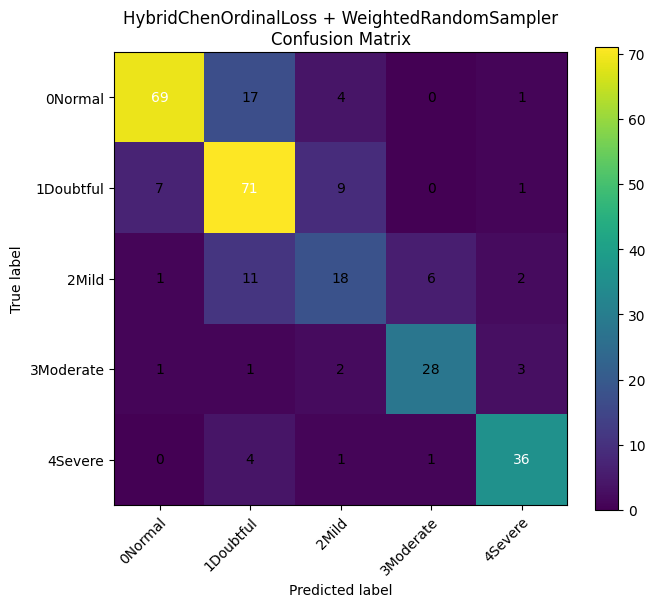

Confusion matrix for: Class-weighted HybridChenOrdinalLoss


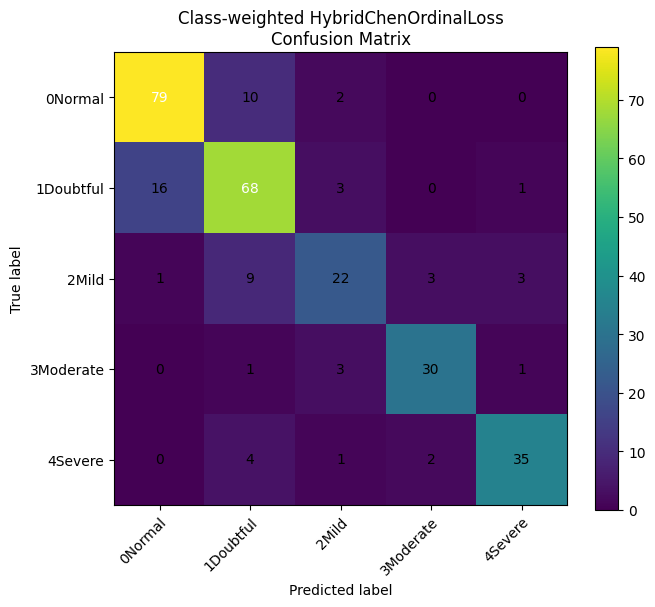

Confusion matrix for: Focal HybridChenOrdinalLoss


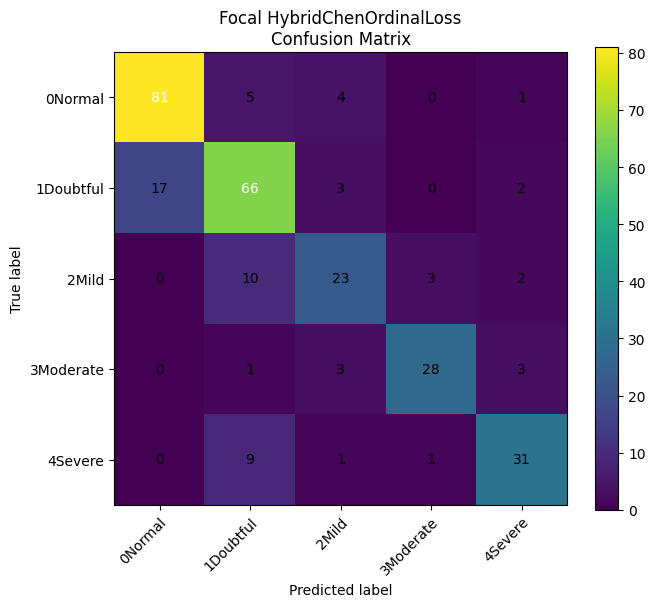

In [64]:
def plot_confusion_matrix_manual(cm, labels, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title,
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

confusion_matrices = {}

for item in IMBALANCE_METHODS:
    method = item["method"]
    display_name = item["display_name"]

    y_true = test_predictions[method]["y_true"]
    y_pred = test_predictions[method]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    confusion_matrices[method] = cm

    print("Confusion matrix for:", display_name)
    plot_confusion_matrix_manual(
        cm,
        class_names,
        title=f"{display_name}\nConfusion Matrix",
        save_path=FIGURES_DIR / f"{method}_confusion_matrix.png"
    )

## 15. Error Analysis

Because this is an ordinal classification task, errors are separated into:

- **Adjacent errors**: prediction differs by 1 grade
- **Distant errors**: prediction differs by 2 or more grades

Distant errors are more clinically problematic.

,method,display_name,correct,adjacent_errors,distant_errors,total_errors,mae,qwk
0,weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,222,56,16,72,0.326531,0.857296
1,class_weighted_loss,Class-weighted HybridChenOrdinalLoss,234,47,13,60,0.265306,0.892399
2,focal_hybrid_loss,Focal HybridChenOrdinalLoss,229,45,20,65,0.333333,0.832195


,count
0,234
1,47
2,8
3,5


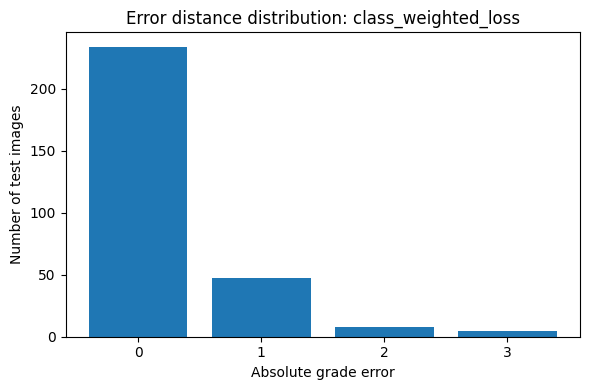

In [65]:
error_analysis_rows = []

for item in IMBALANCE_METHODS:
    method = item["method"]
    display_name = item["display_name"]

    y_true = test_predictions[method]["y_true"]
    y_pred = test_predictions[method]["y_pred"]

    diff = np.abs(y_true - y_pred)

    row = {
        "method": method,
        "display_name": display_name,
        "correct": int(np.sum(diff == 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
        "total_errors": int(np.sum(diff != 0)),
        "mae": float(np.mean(diff)),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
    }
    error_analysis_rows.append(row)

error_analysis_df = pd.DataFrame(error_analysis_rows)
display(error_analysis_df)
error_analysis_df.to_csv(RESULTS_DIR / "error_analysis_comparison.csv", index=False)

final_true = test_predictions[FINAL_METHOD]["y_true"]
final_pred = test_predictions[FINAL_METHOD]["y_pred"]
final_diff = np.abs(final_true - final_pred)

distance_counts = pd.Series(final_diff).value_counts().sort_index()
display(distance_counts.rename("count").to_frame())

plt.figure(figsize=(6, 4))
plt.bar(distance_counts.index.astype(str), distance_counts.values)
plt.xlabel("Absolute grade error")
plt.ylabel("Number of test images")
plt.title(f"Error distance distribution: {FINAL_METHOD}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{FINAL_METHOD}_error_distance_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

### 15.1 Misclassified examples

The examples below are read directly from the original file paths, not from transformed tensors.

wrong samples: 60 / 294


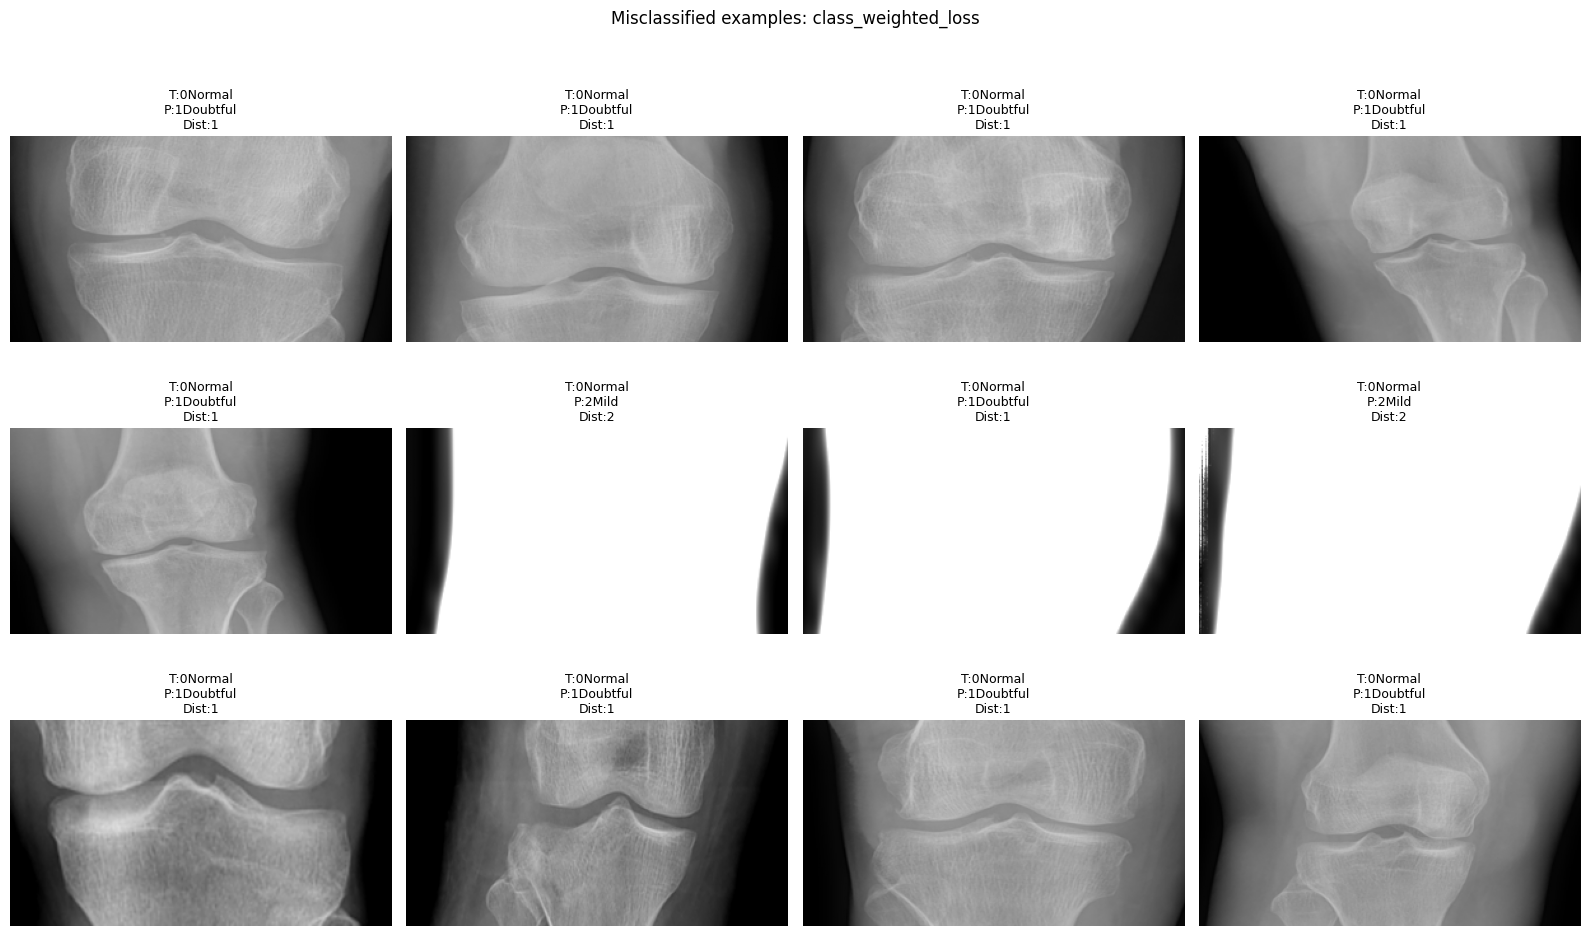

In [66]:
def show_misclassified_raw_images(dataset, y_true, y_pred, max_images=12, title="Misclassified examples"):
    wrong_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if int(t) != int(p)]
    print(f"wrong samples: {len(wrong_indices)} / {len(y_true)}")

    show_indices = wrong_indices[:max_images]
    if len(show_indices) == 0:
        print("No misclassified samples to show.")
        return

    cols = 4
    rows = math.ceil(len(show_indices) / cols)
    plt.figure(figsize=(cols * 4, rows * 3.2))

    for plot_i, idx in enumerate(show_indices, start=1):
        img_path, _ = dataset.samples[idx]
        true_label = int(y_true[idx])
        pred_label = int(y_pred[idx])
        dist = abs(true_label - pred_label)

        img = Image.open(img_path).convert("L")

        plt.subplot(rows, cols, plot_i)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
        plt.title(
            f"T:{class_names[true_label]}\nP:{class_names[pred_label]}\nDist:{dist}",
            fontsize=9
        )

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{FINAL_METHOD}_misclassified_examples.png", dpi=200, bbox_inches="tight")
    plt.show()

show_misclassified_raw_images(
    test_dataset,
    final_true,
    final_pred,
    max_images=12,
    title=f"Misclassified examples: {FINAL_METHOD}"
)

## 16. Grad-CAM

Grad-CAM is used to visually inspect whether the DenseNet121 model focuses on the knee joint area.

The notebook shows one correctly classified example and one misclassified example for the selected final method.

Loaded DenseNet121 ImageNet pretrained weights.


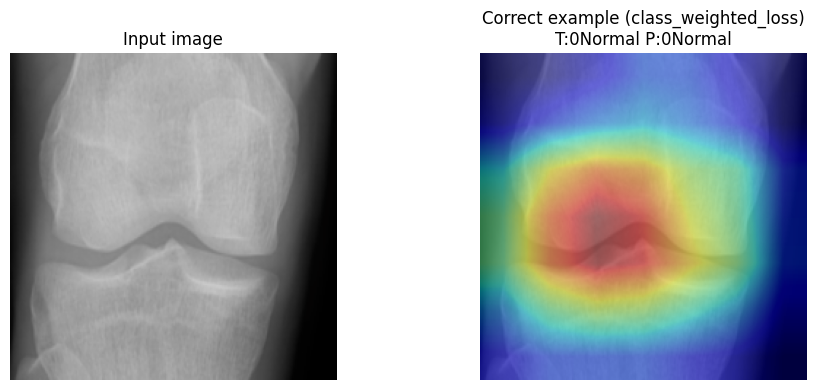

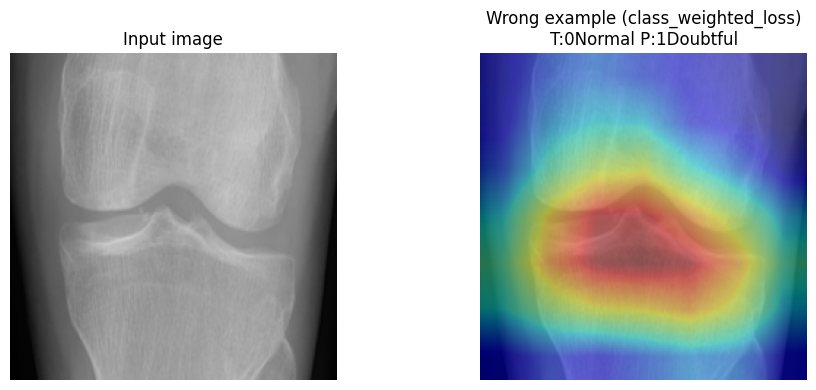

In [67]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self.forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def __call__(self, image_tensor, target_class):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(image_tensor)
        score = logits[:, target_class].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = F.interpolate(
            cam,
            size=image_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

def show_gradcam_for_index(model, dataset, idx, y_true, y_pred, title_prefix="Grad-CAM"):
    model.eval()

    img_tensor, label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    pred_label = int(y_pred[idx])
    true_label = int(y_true[idx])

    target_layer = model.features.denseblock4
    gradcam = GradCAM(model, target_layer)

    cam = gradcam(input_tensor, target_class=pred_label)
    gradcam.remove()

    img_np = denormalize_tensor(img_tensor)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("Input image")

    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    plt.imshow(cam, cmap="jet", alpha=0.45)
    plt.axis("off")
    plt.title(f"{title_prefix}\nT:{class_names[true_label]} P:{class_names[pred_label]}")

    plt.tight_layout()
    plt.show()

final_model, _ = load_model_from_checkpoint(method_paths[FINAL_METHOD])
final_model.eval()

correct_indices = [i for i, (t, p) in enumerate(zip(final_true, final_pred)) if int(t) == int(p)]
wrong_indices = [i for i, (t, p) in enumerate(zip(final_true, final_pred)) if int(t) != int(p)]

if correct_indices:
    show_gradcam_for_index(
        final_model,
        test_dataset,
        correct_indices[0],
        final_true,
        final_pred,
        title_prefix=f"Correct example ({FINAL_METHOD})"
    )

if wrong_indices:
    show_gradcam_for_index(
        final_model,
        test_dataset,
        wrong_indices[0],
        final_true,
        final_pred,
        title_prefix=f"Wrong example ({FINAL_METHOD})"
    )

## 17. Final Summary

# Experiment Conclusion

This experiment compared three class imbalance strategies on top of the selected **single-image DenseNet121 + HybridChenOrdinalLoss** setting.

The three methods were:

1. **WeightedRandomSampler**
2. **Class-weighted HybridChenOrdinalLoss**
3. **Focal HybridChenOrdinalLoss**

The final selected method is based on validation QWK. The test set is then used only for final reporting.

This experiment is important because the training set is imbalanced, with many more `0Normal` and `1Doubtful` images than `2Mild`, `3Moderate`, and `4Severe`. Since knee OA grading is ordinal, the most important metrics are QWK, MAE, and distant errors rather than accuracy alone.

In [68]:
summary = {
    "experiment_name": EXPERIMENT_NAME,
    "config": CONFIG,
    "class_names": class_names,
    "train_class_counts": {class_names[i]: int(train_class_counts[i]) for i in range(len(class_names))},
    "methods": IMBALANCE_METHODS,
    "best_method_by_validation_qwk": best_method_by_val,
    "best_method_by_test_qwk": best_method_by_test_qwk,
    "selected_final_method": FINAL_METHOD,
    "test_results": test_results,
}

print("Final selected method:", FINAL_METHOD)
print("\nTest result summary:")
display(results_df)

print("\nError analysis summary:")
display(error_analysis_df)

Final selected method: class_weighted_loss

Test result summary:


,display_name,best_epoch,best_val_qwk,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,loss,ce_or_focal_part,ordinal_part
weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,3,0.90362,0.755102,0.740642,0.754991,0.857296,0.326531,72,56,16,0.759174,0.746256,0.12918
class_weighted_loss,Class-weighted HybridChenOrdinalLoss,13,0.921025,0.795918,0.789792,0.794089,0.892399,0.265306,60,47,13,0.73113,0.721278,0.098511
focal_hybrid_loss,Focal HybridChenOrdinalLoss,18,0.91472,0.778912,0.766943,0.777461,0.832195,0.333333,65,45,20,0.444605,0.431807,0.127986



Error analysis summary:


,method,display_name,correct,adjacent_errors,distant_errors,total_errors,mae,qwk
0,weighted_sampler,HybridChenOrdinalLoss + WeightedRandomSampler,222,56,16,72,0.326531,0.857296
1,class_weighted_loss,Class-weighted HybridChenOrdinalLoss,234,47,13,60,0.265306,0.892399
2,focal_hybrid_loss,Focal HybridChenOrdinalLoss,229,45,20,65,0.333333,0.832195


## 18. Save Results

The notebook saves:

- `metrics.json`
- per-method `confusion_matrix.png`
- `imbalance_method_test_results.csv`
- `classwise_recall_f1_comparison.csv`
- `error_analysis_comparison.csv`
- training histories

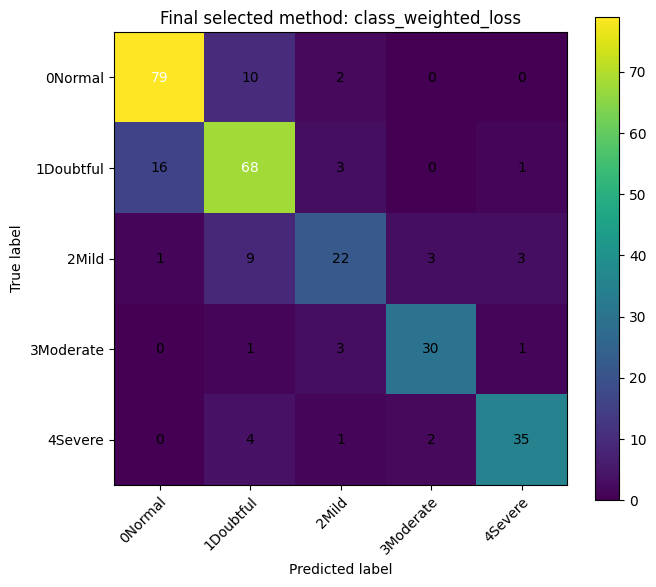

Saved metrics to: /kaggle/working/exp03_single_image_hybrid_chen_imbalance_comparison/results/metrics.json
Saved summary to: /kaggle/working/exp03_single_image_hybrid_chen_imbalance_comparison/results/summary.json
Saved final confusion matrix to: /kaggle/working/exp03_single_image_hybrid_chen_imbalance_comparison/figures/confusion_matrix.png
All outputs saved under: /kaggle/working/exp03_single_image_hybrid_chen_imbalance_comparison


In [69]:
metrics_path = RESULTS_DIR / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(summary, f, indent=2)

final_cm = confusion_matrices[FINAL_METHOD]
final_cm_path = FIGURES_DIR / "confusion_matrix.png"
plot_confusion_matrix_manual(
    final_cm,
    class_names,
    title=f"Final selected method: {FINAL_METHOD}",
    save_path=final_cm_path
)

summary_path = RESULTS_DIR / "summary.json"
with open(summary_path, "w") as f:
    json.dump({
        "experiment_name": EXPERIMENT_NAME,
        "selected_final_method": FINAL_METHOD,
        "best_method_by_validation_qwk": best_method_by_val,
        "best_method_by_test_qwk": best_method_by_test_qwk,
        "final_test_metrics": test_results[FINAL_METHOD],
        "output_dir": str(OUTPUT_DIR),
    }, f, indent=2)

print("Saved metrics to:", metrics_path)
print("Saved summary to:", summary_path)
print("Saved final confusion matrix to:", final_cm_path)
print("All outputs saved under:", OUTPUT_DIR)